In [1]:
import pm4py
import pandas as pd
import utils
import mdp
import trace_test
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.log.obj import EventLog, Trace, Event
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments
import numpy as np

# PART 1

In [2]:
# Import the log
log = xes_importer.apply('Synthetic event logs - review example large.xes.gz_1_all/review_example_large.xes.gz')

log_df = pm4py.convert_to_dataframe(log)
log_df

c:\Users\danip\anaconda3\envs\bdss-lab\lib\site-packages\pm4py\util\dt_parsing\parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/10000 [00:00<?, ?it/s]

,org:resource,time:timestamp,concept:name,lifecycle:transition,case:concept:name,case:description,result
0,Mike,2006-01-01 00:00:00+00:00,invite reviewers,start,1,Simulated process instance,NaN
1,Mike,2006-01-05 00:00:00+00:00,invite reviewers,complete,1,Simulated process instance,NaN
2,Mary,2006-01-05 00:00:00+00:00,get review 3,complete,1,Simulated process instance,reject
3,Pam,2006-01-06 00:00:00+00:00,get review 1,complete,1,Simulated process instance,reject
4,__INVALID__,2006-01-15 00:00:00+00:00,time-out 2,complete,1,Simulated process instance,NaN
...,...,...,...,...,...,...,...
236355,Anne,2223-07-17 01:00:00+00:00,invite additional reviewer,start,9999,Simulated process instance,NaN
236356,Anne,2223-07-17 01:00:00+00:00,invite additional reviewer,complete,9999,Simulated process instance,NaN
236357,Sam,2223-07-21 01:00:00+00:00,get review X,complete,9999,Simulated process instance,accept
236358,Mike,2223-08-06 01:00:00+00:00,accept,start,9999,Simulated process instance,NaN


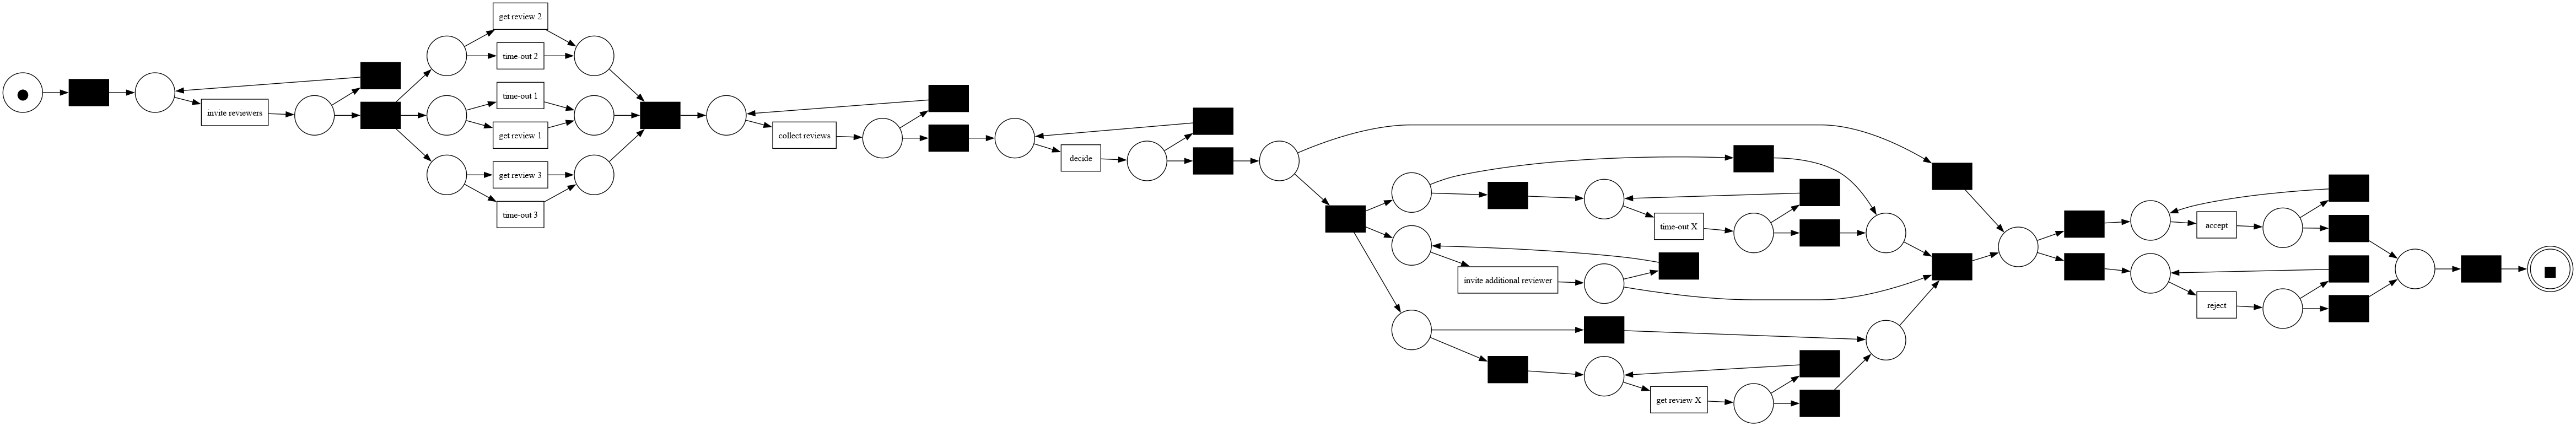

In [3]:
# Build the Petri net
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log)
pm4py.view_petri_net(net, initial_marking, final_marking)

In [4]:
# Alignment between log and Petri net
parameter = {alignments.Parameters.PARAM_ALIGNMENT_RESULT_IS_SYNC_PROD_AWARE: True}
standard_alignments = alignments.apply_log(log, net, initial_marking, final_marking, parameters=parameter)

standard_alignments_df = pd.DataFrame(standard_alignments)
standard_alignments_df

aligning log, completed variants ::   0%|          | 0/4118 [00:00<?, ?it/s]

,alignment,cost,visited_states,queued_states,traversed_arcs,lp_solved,fitness,bwc
0,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",18,53,164,177,16,1.0,210009
1,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",33,196,574,720,29,1.0,360009
2,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",30,208,600,764,37,1.0,330009
3,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",36,200,593,747,27,1.0,390009
4,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",42,296,857,1086,35,1.0,450009
...,...,...,...,...,...,...,...,...
9995,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",24,127,369,454,30,1.0,270009
9996,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",24,115,339,414,29,1.0,270009
9997,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",24,123,356,436,29,1.0,270009
9998,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",18,50,155,162,14,1.0,210009


In [5]:
standard_alignments_df['alignment'][0]

[(('>>', 'tau_1'), ('>>', None)),
 (('t_invite reviewers_0', '62870cb1-1223-48a8-8d2e-7f5e25de7fa9'),
  ('invite reviewers', 'invite reviewers')),
 (('>>', 'skip_5'), ('>>', None)),
 (('t_invite reviewers_1', '62870cb1-1223-48a8-8d2e-7f5e25de7fa9'),
  ('invite reviewers', 'invite reviewers')),
 (('>>', 'skip_6'), ('>>', None)),
 (('t_get review 3_2', '6106f794-54d7-42a6-85a5-86d191e073e1'),
  ('get review 3', 'get review 3')),
 (('t_get review 1_3', '61fac5e7-57a8-49e4-af2e-13db5a9c3acb'),
  ('get review 1', 'get review 1')),
 (('t_time-out 2_4', '62108323-c230-47df-a8b8-3aea1b2b6595'),
  ('time-out 2', 'time-out 2')),
 (('>>', 'tauJoin_8'), ('>>', None)),
 (('t_collect reviews_5', '14d43b93-55db-4e0c-98a3-f92a2860e05d'),
  ('collect reviews', 'collect reviews')),
 (('>>', 'skip_11'), ('>>', None)),
 (('t_collect reviews_6', '14d43b93-55db-4e0c-98a3-f92a2860e05d'),
  ('collect reviews', 'collect reviews')),
 (('>>', 'skip_12'), ('>>', None)),
 (('t_decide_7', '972552c8-a256-4fe6-a671-c

In [6]:
# Construction of the aligned log
aligned_log = utils.compute_aligned_log(log, standard_alignments)

aligned_log_df = pm4py.convert_to_dataframe(aligned_log)
aligned_log_df

Aligned Log built with 10000 traces.


,concept:name,org:resource,time:timestamp,lifecycle:transition,case:concept:name,case:description,result
0,invite reviewers,Mike,2006-01-01 00:00:00+00:00,start,1,Simulated process instance,NaN
1,invite reviewers,Mike,2006-01-05 00:00:00+00:00,complete,1,Simulated process instance,NaN
2,get review 3,Mary,2006-01-05 00:00:00+00:00,complete,1,Simulated process instance,reject
3,get review 1,Pam,2006-01-06 00:00:00+00:00,complete,1,Simulated process instance,reject
4,time-out 2,__INVALID__,2006-01-15 00:00:00+00:00,complete,1,Simulated process instance,NaN
...,...,...,...,...,...,...,...
236355,invite additional reviewer,Anne,2223-07-17 01:00:00+00:00,start,9999,Simulated process instance,NaN
236356,invite additional reviewer,Anne,2223-07-17 01:00:00+00:00,complete,9999,Simulated process instance,NaN
236357,get review X,Sam,2223-07-21 01:00:00+00:00,complete,9999,Simulated process instance,accept
236358,accept,Mike,2223-08-06 01:00:00+00:00,start,9999,Simulated process instance,NaN


In [7]:
# Alignment between the aligned log and the Petri net
perfect_alignment = alignments.apply_log(aligned_log, net, initial_marking, final_marking, parameters=parameter)

perfect_alignment_df = pd.DataFrame(perfect_alignment)
perfect_alignment_df

aligning log, completed variants ::   0%|          | 0/4118 [00:00<?, ?it/s]

,alignment,cost,visited_states,queued_states,traversed_arcs,lp_solved,fitness,bwc
0,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",18,50,155,162,14,1.0,210009
1,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",33,193,564,702,27,1.0,360009
2,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",30,145,430,530,27,1.0,330009
3,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",36,135,443,518,20,1.0,390009
4,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",42,292,844,1077,37,1.0,450009
...,...,...,...,...,...,...,...,...
9995,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",24,127,369,454,32,1.0,270009
9996,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",24,107,323,373,24,1.0,270009
9997,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",24,123,356,441,30,1.0,270009
9998,"[((>>, tau_1), (>>, None)), ((t_invite reviewe...",18,53,164,177,16,1.0,210009


In [8]:
perfect_alignment_df['alignment'][0]

[(('>>', 'tau_1'), ('>>', None)),
 (('t_invite reviewers_0', '62870cb1-1223-48a8-8d2e-7f5e25de7fa9'),
  ('invite reviewers', 'invite reviewers')),
 (('>>', 'skip_5'), ('>>', None)),
 (('t_invite reviewers_1', '62870cb1-1223-48a8-8d2e-7f5e25de7fa9'),
  ('invite reviewers', 'invite reviewers')),
 (('>>', 'skip_6'), ('>>', None)),
 (('t_get review 3_2', '6106f794-54d7-42a6-85a5-86d191e073e1'),
  ('get review 3', 'get review 3')),
 (('t_get review 1_3', '61fac5e7-57a8-49e4-af2e-13db5a9c3acb'),
  ('get review 1', 'get review 1')),
 (('t_time-out 2_4', '62108323-c230-47df-a8b8-3aea1b2b6595'),
  ('time-out 2', 'time-out 2')),
 (('>>', 'tauJoin_8'), ('>>', None)),
 (('t_collect reviews_5', '14d43b93-55db-4e0c-98a3-f92a2860e05d'),
  ('collect reviews', 'collect reviews')),
 (('>>', 'skip_11'), ('>>', None)),
 (('t_collect reviews_6', '14d43b93-55db-4e0c-98a3-f92a2860e05d'),
  ('collect reviews', 'collect reviews')),
 (('>>', 'skip_12'), ('>>', None)),
 (('t_decide_7', '972552c8-a256-4fe6-a671-c

# PART 2

In [ ]:
# Build the MDP
automata = mdp.AutomataWrapper(net, initial_marking, final_marking, perfect_alignment)
states = automata.generate_mdp(aligned_log)

for state in sorted(states.values(), key=lambda n: n.index):
    print(state)

process_entropy = utils.calculate_process_entropy(states, aligned_log)
print("------------------------------")
print(f"Process Entropy: {process_entropy:.4f}")
print("------------------------------")

## First Trace Test

In [ ]:
psi_review = trace_test.Literal(lambda e: 'get review' in e['concept:name'], 'review')
psi_accept = trace_test.Literal(lambda e: e['result'] == 'accept', 'accept paper')
psi_review_accept = trace_test.And(psi_review, psi_accept)
review_accept_test = trace_test.TraceTest(psi_review_accept.description, psi_review_accept, time=None)
state_datasets = review_accept_test.generate_state_datasets(states, perfect_alignment)

for key, (dataset, sat_set, unsat_set) in state_datasets.items():
    print(f"State: {key}\n\t - Dataset size: {len(dataset)}\n\t - Sat set size: {len(sat_set)} | Unsat set size: {len(unsat_set)}\n\t - Sat entropy: {utils.calculate_subset_entropy(sat_set):.4f} | Unsat entropy: {utils.calculate_subset_entropy(unsat_set):.4f}\n")

trace_test_entropy = utils.calculate_trace_test_entropy(state_datasets, states, aligned_log)
information_gain = process_entropy - trace_test_entropy
print(f'--------------------------------')
print(f"- Trace test entropy: {trace_test_entropy:.4f}\n- Information gain: {information_gain:.4f}")
print(f'--------------------------------')

## Second Trace Test

In [ ]:
psi_timeout = trace_test.Literal(lambda e: 'time-out' in e['concept:name'], 'time-out occurred ever')
timeout_test_ever = trace_test.TraceTest(psi_timeout.description, psi_timeout, time=np.inf)
state_datasets = timeout_test_ever.generate_state_datasets(states, perfect_alignment)

for key, (dataset, sat_set, unsat_set) in state_datasets.items():
    print(f"State: {key}\n\t - Dataset size: {len(dataset)}\n\t - Sat set size: {len(sat_set)} | Unsat set size: {len(unsat_set)}\n\t - Sat entropy: {utils.calculate_subset_entropy(sat_set):.4f} | Unsat entropy: {utils.calculate_subset_entropy(unsat_set):.4f}\n")

trace_test_entropy = utils.calculate_trace_test_entropy(state_datasets, states, aligned_log)
information_gain = process_entropy - trace_test_entropy
print(f'--------------------------------')
print(f"- Trace test entropy: {trace_test_entropy:.4f}\n- Information gain: {information_gain:.4f}")
print(f'--------------------------------')

## Third Trace Test

In [ ]:
psi_reject = trace_test.Literal(lambda e: e.get('result') == 'reject', 'rejection in at most 10 seconds')
reject_test = trace_test.TraceTest(psi_reject.description, psi_reject, time=10.0)
state_datasets = reject_test.generate_state_datasets(states, perfect_alignment)

for key, (dataset, sat_set, unsat_set) in state_datasets.items():
    print(f"State: {key}\n\t - Dataset size: {len(dataset)}\n\t - Sat set size: {len(sat_set)} | Unsat set size: {len(unsat_set)}\n\t - Sat entropy: {utils.calculate_subset_entropy(sat_set):.4f} | Unsat entropy: {utils.calculate_subset_entropy(unsat_set):.4f}\n")

trace_test_entropy = utils.calculate_trace_test_entropy(state_datasets, states, aligned_log)
information_gain = process_entropy - trace_test_entropy
print(f'--------------------------------')
print(f"- Trace test entropy: {trace_test_entropy:.4f}\n- Information gain: {information_gain:.4f}")
print(f'--------------------------------')

## Fourth Trace Test

In [ ]:
psi_mary = trace_test.Literal(lambda e: e.get('org:resource') == 'John', 'John')
psi_reject = trace_test.Literal(lambda e: e.get('result') == 'reject', 'rejection')
psi_mary_rejection = trace_test.And(psi_mary, trace_test.Not(psi_reject))
mary_rejection_test = trace_test.TraceTest(psi_mary_rejection.description, psi_mary_rejection, time=None)
state_datasets = mary_rejection_test.generate_state_datasets(states, perfect_alignment)

for key, (dataset, sat_set, unsat_set) in state_datasets.items():
    print(f"State: {key}\n\t - Dataset size: {len(dataset)}\n\t - Sat set size: {len(sat_set)} | Unsat set size: {len(unsat_set)}\n\t - Sat entropy: {utils.calculate_subset_entropy(sat_set):.4f} | Unsat entropy: {utils.calculate_subset_entropy(unsat_set):.4f}\n")

trace_test_entropy = utils.calculate_trace_test_entropy(state_datasets, states, aligned_log)
information_gain = process_entropy - trace_test_entropy
print(f'--------------------------------')
print(f"- Trace test entropy: {trace_test_entropy:.4f}\n- Information gain: {information_gain:.4f}")
print(f'--------------------------------')

## Fifth Trace Test

In [ ]:
psi_review = trace_test.Literal(lambda e: 'get review' in e['concept:name'], 'any get review in at most 60 days')
review_test = trace_test.TraceTest(psi_review.description, psi_review, time=5184000.0)
state_datasets = review_test.generate_state_datasets(states, perfect_alignment)

for key, (dataset, sat_set, unsat_set) in state_datasets.items():
    print(f"State: {key}\n\t - Dataset size: {len(dataset)}\n\t - Sat set size: {len(sat_set)} | Unsat set size: {len(unsat_set)}\n\t - Sat entropy: {utils.calculate_subset_entropy(sat_set):.4f} | Unsat entropy: {utils.calculate_subset_entropy(unsat_set):.4f}\n")

trace_test_entropy = utils.calculate_trace_test_entropy(state_datasets, states, aligned_log)
information_gain = process_entropy - trace_test_entropy
print(f'--------------------------------')
print(f"- Trace test entropy: {trace_test_entropy:.4f}\n- Information gain: {abs(information_gain):.4f}")
print(f'--------------------------------')

# PART 3

## Log A

In [15]:
# Relabeling log with one trace test
set_a = [review_accept_test]
log_a = utils.generate_relabeled_log(log, set_a)

log_a_df = pm4py.convert_to_dataframe(log_a)
log_a_df

Relabeling log with 1 tests...


  0%|          | 0/10000 [00:00<?, ?it/s]

Success! Relabeling completed.


,org:resource,time:timestamp,concept:name,lifecycle:transition,case:concept:name,case:description,result
0,Mike,2006-01-01 00:00:00+00:00,invite reviewers_[0],start,1,Simulated process instance,NaN
1,Mike,2006-01-05 00:00:00+00:00,invite reviewers_[0],complete,1,Simulated process instance,NaN
2,Mary,2006-01-05 00:00:00+00:00,get review 3_[0],complete,1,Simulated process instance,reject
3,Pam,2006-01-06 00:00:00+00:00,get review 1_[0],complete,1,Simulated process instance,reject
4,__INVALID__,2006-01-15 00:00:00+00:00,time-out 2_[0],complete,1,Simulated process instance,NaN
...,...,...,...,...,...,...,...
236355,Anne,2223-07-17 01:00:00+00:00,invite additional reviewer_[1],start,9999,Simulated process instance,NaN
236356,Anne,2223-07-17 01:00:00+00:00,invite additional reviewer_[1],complete,9999,Simulated process instance,NaN
236357,Sam,2223-07-21 01:00:00+00:00,get review X_[1],complete,9999,Simulated process instance,accept
236358,Mike,2223-08-06 01:00:00+00:00,accept_[1],start,9999,Simulated process instance,NaN


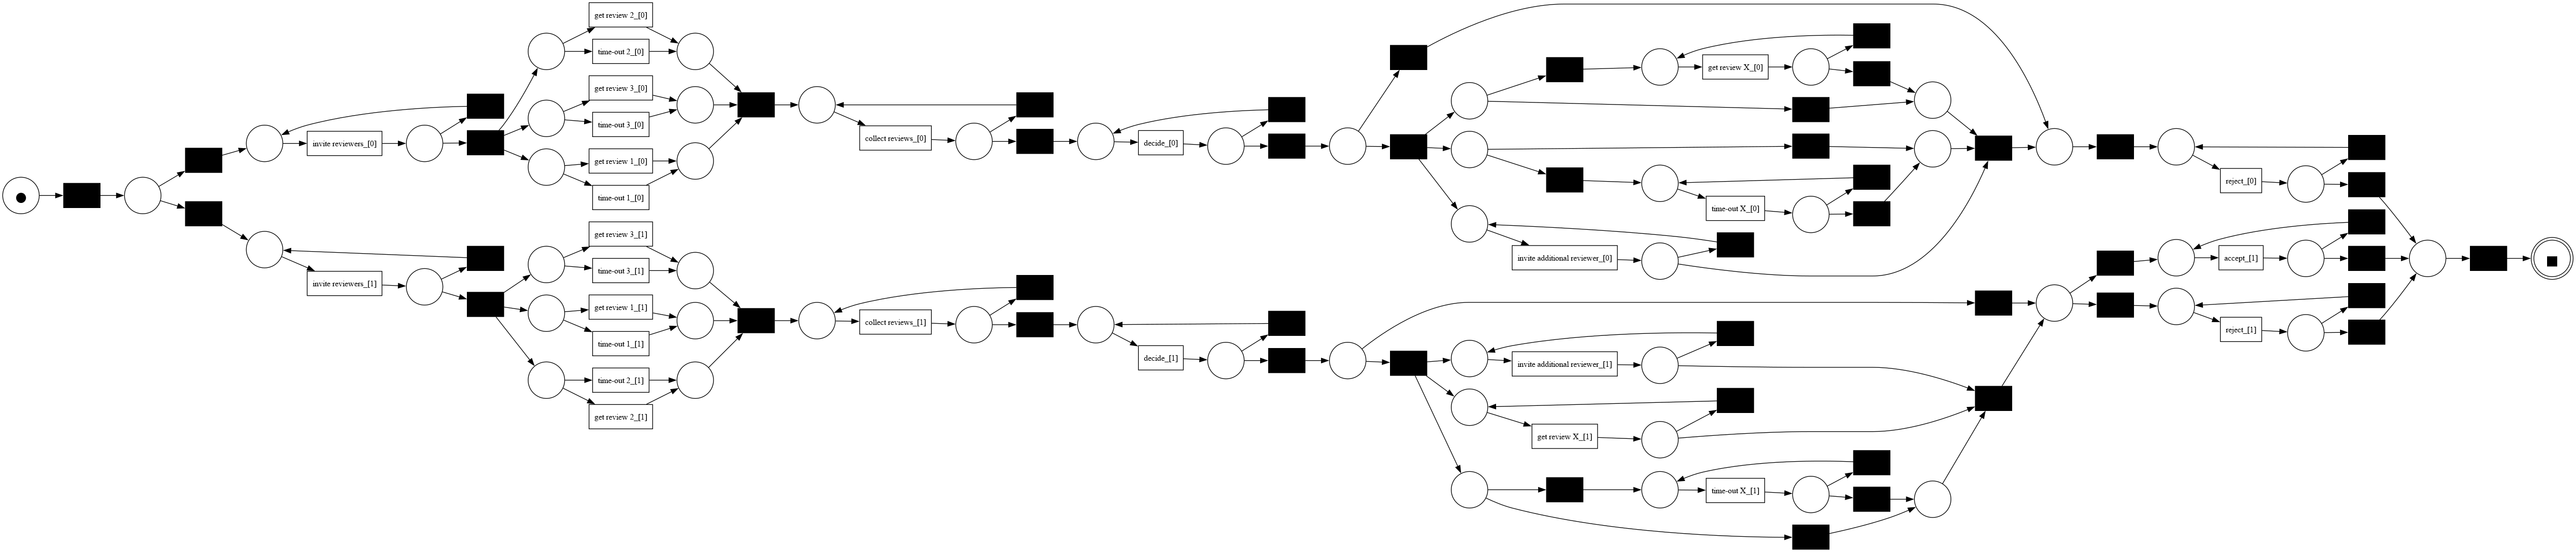

In [16]:
# Build the Petri net from the log A
net_a, initial_marking_a, final_marking_a = pm4py.discover_petri_net_inductive(log_a)
pm4py.view_petri_net(net_a, initial_marking_a, final_marking_a)

In [17]:
parameter = {alignments.Parameters.PARAM_ALIGNMENT_RESULT_IS_SYNC_PROD_AWARE: True}
standard_alignments_a = alignments.apply_log(log_a, net_a, initial_marking_a, final_marking_a, parameters=parameter)

standard_alignments_df_a = pd.DataFrame(standard_alignments_a)
standard_alignments_df_a.head()

aligning log, completed variants ::   0%|          | 0/4209 [00:00<?, ?it/s]

,alignment,cost,visited_states,queued_states,traversed_arcs,lp_solved,fitness,bwc
0,"[((>>, tau_1), (>>, None)), ((>>, init_loop_3)...",19,50,149,155,10,1.0,210010
1,"[((>>, tau_1), (>>, None)), ((>>, init_loop_38...",32,113,379,431,8,1.0,360010
2,"[((>>, tau_1), (>>, None)), ((>>, init_loop_38...",29,71,255,273,6,1.0,330010
3,"[((>>, tau_1), (>>, None)), ((>>, init_loop_38...",35,84,312,338,6,1.0,390010
4,"[((>>, tau_1), (>>, None)), ((>>, init_loop_38...",41,162,540,626,12,1.0,450010


In [18]:
standard_alignments_df_a['alignment'][0]

[(('>>', 'tau_1'), ('>>', None)),
 (('>>', 'init_loop_3'), ('>>', None)),
 (('t_invite reviewers_[0]_0', '37bbc62b-c208-457f-9f74-071fa0ad2571'),
  ('invite reviewers_[0]', 'invite reviewers_[0]')),
 (('>>', 'skip_5'), ('>>', None)),
 (('t_invite reviewers_[0]_1', '37bbc62b-c208-457f-9f74-071fa0ad2571'),
  ('invite reviewers_[0]', 'invite reviewers_[0]')),
 (('>>', 'skip_6'), ('>>', None)),
 (('t_get review 3_[0]_2', 'b82f55e0-8783-4a34-96cf-daecd02ffa94'),
  ('get review 3_[0]', 'get review 3_[0]')),
 (('t_get review 1_[0]_3', 'd947ec2f-f2a3-4461-9a3e-204d26b9d84b'),
  ('get review 1_[0]', 'get review 1_[0]')),
 (('t_time-out 2_[0]_4', 'c5d24d3a-1065-4058-bf4f-d4ddca86a836'),
  ('time-out 2_[0]', 'time-out 2_[0]')),
 (('>>', 'tauJoin_8'), ('>>', None)),
 (('t_collect reviews_[0]_5', '5f6dcc59-f871-46ea-9a85-51f03a7cb09e'),
  ('collect reviews_[0]', 'collect reviews_[0]')),
 (('>>', 'skip_11'), ('>>', None)),
 (('t_collect reviews_[0]_6', '5f6dcc59-f871-46ea-9a85-51f03a7cb09e'),
  ('co

In [19]:
aligned_log_a = utils.compute_aligned_log(log_a, standard_alignments_a)

aligned_log_df_a = pm4py.convert_to_dataframe(aligned_log_a)
aligned_log_df_a

Aligned Log built with 10000 traces.


,concept:name,org:resource,time:timestamp,lifecycle:transition,case:concept:name,case:description,result
0,invite reviewers_[0],Mike,2006-01-01 00:00:00+00:00,start,1,Simulated process instance,NaN
1,invite reviewers_[0],Mike,2006-01-05 00:00:00+00:00,complete,1,Simulated process instance,NaN
2,get review 3_[0],Mary,2006-01-05 00:00:00+00:00,complete,1,Simulated process instance,reject
3,get review 1_[0],Pam,2006-01-06 00:00:00+00:00,complete,1,Simulated process instance,reject
4,time-out 2_[0],__INVALID__,2006-01-15 00:00:00+00:00,complete,1,Simulated process instance,NaN
...,...,...,...,...,...,...,...
236355,invite additional reviewer_[1],Anne,2223-07-17 01:00:00+00:00,start,9999,Simulated process instance,NaN
236356,invite additional reviewer_[1],Anne,2223-07-17 01:00:00+00:00,complete,9999,Simulated process instance,NaN
236357,get review X_[1],Sam,2223-07-21 01:00:00+00:00,complete,9999,Simulated process instance,accept
236358,accept_[1],Mike,2223-08-06 01:00:00+00:00,start,9999,Simulated process instance,NaN


In [20]:
perfect_alignment_a = alignments.apply_log(aligned_log_a, net_a, initial_marking_a, final_marking_a, parameters=parameter)

perfect_alignment_df_a = pd.DataFrame(perfect_alignment_a)
perfect_alignment_df_a.head()

aligning log, completed variants ::   0%|          | 0/4209 [00:00<?, ?it/s]

,alignment,cost,visited_states,queued_states,traversed_arcs,lp_solved,fitness,bwc
0,"[((>>, tau_1), (>>, None)), ((>>, init_loop_3)...",19,50,149,155,9,1.0,210010
1,"[((>>, tau_1), (>>, None)), ((>>, init_loop_38...",32,113,379,431,9,1.0,360010
2,"[((>>, tau_1), (>>, None)), ((>>, init_loop_38...",29,71,255,275,6,1.0,330010
3,"[((>>, tau_1), (>>, None)), ((>>, init_loop_38...",35,132,429,495,12,1.0,390010
4,"[((>>, tau_1), (>>, None)), ((>>, init_loop_38...",41,98,374,406,6,1.0,450010


In [21]:
perfect_alignment_df_a['alignment'][0]

[(('>>', 'tau_1'), ('>>', None)),
 (('>>', 'init_loop_3'), ('>>', None)),
 (('t_invite reviewers_[0]_0', '37bbc62b-c208-457f-9f74-071fa0ad2571'),
  ('invite reviewers_[0]', 'invite reviewers_[0]')),
 (('>>', 'skip_5'), ('>>', None)),
 (('t_invite reviewers_[0]_1', '37bbc62b-c208-457f-9f74-071fa0ad2571'),
  ('invite reviewers_[0]', 'invite reviewers_[0]')),
 (('>>', 'skip_6'), ('>>', None)),
 (('t_get review 3_[0]_2', 'b82f55e0-8783-4a34-96cf-daecd02ffa94'),
  ('get review 3_[0]', 'get review 3_[0]')),
 (('t_get review 1_[0]_3', 'd947ec2f-f2a3-4461-9a3e-204d26b9d84b'),
  ('get review 1_[0]', 'get review 1_[0]')),
 (('t_time-out 2_[0]_4', 'c5d24d3a-1065-4058-bf4f-d4ddca86a836'),
  ('time-out 2_[0]', 'time-out 2_[0]')),
 (('>>', 'tauJoin_8'), ('>>', None)),
 (('t_collect reviews_[0]_5', '5f6dcc59-f871-46ea-9a85-51f03a7cb09e'),
  ('collect reviews_[0]', 'collect reviews_[0]')),
 (('>>', 'skip_11'), ('>>', None)),
 (('t_collect reviews_[0]_6', '5f6dcc59-f871-46ea-9a85-51f03a7cb09e'),
  ('co

In [ ]:
# Build the MDP associated to the log A
automata_a = mdp.AutomataWrapper(net_a, initial_marking_a, final_marking_a, perfect_alignment_a)
states_a = automata_a.generate_mdp(aligned_log_a)

for state in sorted(states_a.values(), key=lambda n: n.index):
    print(state)

process_entropy_a = utils.calculate_process_entropy(states_a, aligned_log_a)
print("------------------------------")
print(f"Process Entropy: {process_entropy_a:.4f}")
print("------------------------------")

## Log B

In [23]:
# Relabeling log with multiple trace tests
set_b = [reject_test, mary_rejection_test, timeout_test_ever, review_test]
log_b = utils.generate_relabeled_log(log, set_b)

log_b_df = pm4py.convert_to_dataframe(log_b)
log_b_df

Relabeling log with 4 tests...


  0%|          | 0/10000 [00:00<?, ?it/s]

Success! Relabeling completed.


,org:resource,time:timestamp,concept:name,lifecycle:transition,case:concept:name,case:description,result
0,Mike,2006-01-01 00:00:00+00:00,"invite reviewers_[1,0,1,1]",start,1,Simulated process instance,NaN
1,Mike,2006-01-05 00:00:00+00:00,"invite reviewers_[1,0,1,1]",complete,1,Simulated process instance,NaN
2,Mary,2006-01-05 00:00:00+00:00,"get review 3_[1,0,1,1]",complete,1,Simulated process instance,reject
3,Pam,2006-01-06 00:00:00+00:00,"get review 1_[1,0,1,1]",complete,1,Simulated process instance,reject
4,__INVALID__,2006-01-15 00:00:00+00:00,"time-out 2_[1,0,1,1]",complete,1,Simulated process instance,NaN
...,...,...,...,...,...,...,...
236355,Anne,2223-07-17 01:00:00+00:00,"invite additional reviewer_[0,0,1,1]",start,9999,Simulated process instance,NaN
236356,Anne,2223-07-17 01:00:00+00:00,"invite additional reviewer_[0,0,1,1]",complete,9999,Simulated process instance,NaN
236357,Sam,2223-07-21 01:00:00+00:00,"get review X_[0,0,1,1]",complete,9999,Simulated process instance,accept
236358,Mike,2223-08-06 01:00:00+00:00,"accept_[0,0,1,1]",start,9999,Simulated process instance,NaN


In [24]:
# Build the Petri net of the log B
net_b, initial_marking_b, final_marking_b = pm4py.discover_petri_net_inductive(log_b)
pm4py.view_petri_net(net_b, initial_marking_b, final_marking_b)

In [25]:
parameter = {alignments.Parameters.PARAM_ALIGNMENT_RESULT_IS_SYNC_PROD_AWARE: True}
standard_alignments_b = alignments.apply_log(log_b, net_b, initial_marking_b, final_marking_b, parameters=parameter)

standard_alignments_df_b = pd.DataFrame(standard_alignments_b)
standard_alignments_df_b.head()

aligning log, completed variants ::   0%|          | 0/5982 [00:00<?, ?it/s]

,alignment,cost,visited_states,queued_states,traversed_arcs,lp_solved,fitness,bwc
0,"[((>>, tau_1), (>>, None)), ((>>, tauSplit_69)...",31,73,210,374,15,1.0,140010
1,"[((>>, tau_1), (>>, None)), ((>>, tauSplit_69)...",61,163,405,839,31,1.0,290010
2,"[((>>, tau_1), (>>, None)), ((>>, tauSplit_69)...",55,145,366,746,29,1.0,260010
3,"[((>>, tau_1), (>>, None)), ((>>, tauSplit_69)...",67,181,444,932,35,1.0,320010
4,"[((>>, tau_1), (>>, None)), ((>>, tauSplit_69)...",79,217,522,1118,35,1.0,380010


In [26]:
standard_alignments_df_b['alignment'][0]

[(('>>', 'tau_1'), ('>>', None)),
 (('>>', 'tauSplit_69'), ('>>', None)),
 (('>>', 'skip_71'), ('>>', None)),
 (('>>', 'init_loop_77'), ('>>', None)),
 (('t_invite reviewers_[1,0,1,1]_0', '766b17f2-b387-4c67-881a-35ef1310a34a'),
  ('invite reviewers_[1,0,1,1]', 'invite reviewers_[1,0,1,1]')),
 (('>>', 'skip_79'), ('>>', None)),
 (('t_invite reviewers_[1,0,1,1]_1', '766b17f2-b387-4c67-881a-35ef1310a34a'),
  ('invite reviewers_[1,0,1,1]', 'invite reviewers_[1,0,1,1]')),
 (('>>', 'skip_80'), ('>>', None)),
 (('t_get review 3_[1,0,1,1]_2', '3207fdd0-84f8-405a-8654-9879efe2a30b'),
  ('get review 3_[1,0,1,1]', 'get review 3_[1,0,1,1]')),
 (('t_get review 1_[1,0,1,1]_3', 'f7c7cd0e-978b-49df-a4e4-652c4047bc99'),
  ('get review 1_[1,0,1,1]', 'get review 1_[1,0,1,1]')),
 (('t_time-out 2_[1,0,1,1]_4', '47555a71-905b-45d0-8f03-9c81db6745da'),
  ('time-out 2_[1,0,1,1]', 'time-out 2_[1,0,1,1]')),
 (('>>', 'tauJoin_82'), ('>>', None)),
 (('>>', 'init_loop_86'), ('>>', None)),
 (('>>', 'init_loop_88')

In [27]:
aligned_log_b = utils.compute_aligned_log(log_b, standard_alignments_b)

aligned_log_df_b = pm4py.convert_to_dataframe(aligned_log_b)
aligned_log_df_b

Aligned Log built with 10000 traces.


,concept:name,org:resource,time:timestamp,lifecycle:transition,case:concept:name,case:description,result
0,"invite reviewers_[1,0,1,1]",Mike,2006-01-01 00:00:00+00:00,start,1,Simulated process instance,NaN
1,"invite reviewers_[1,0,1,1]",Mike,2006-01-05 00:00:00+00:00,complete,1,Simulated process instance,NaN
2,"get review 3_[1,0,1,1]",Mary,2006-01-05 00:00:00+00:00,complete,1,Simulated process instance,reject
3,"get review 1_[1,0,1,1]",Pam,2006-01-06 00:00:00+00:00,complete,1,Simulated process instance,reject
4,"time-out 2_[1,0,1,1]",__INVALID__,2006-01-15 00:00:00+00:00,complete,1,Simulated process instance,NaN
...,...,...,...,...,...,...,...
236355,"invite additional reviewer_[0,0,1,1]",Anne,2223-07-17 01:00:00+00:00,start,9999,Simulated process instance,NaN
236356,"invite additional reviewer_[0,0,1,1]",Anne,2223-07-17 01:00:00+00:00,complete,9999,Simulated process instance,NaN
236357,"get review X_[0,0,1,1]",Sam,2223-07-21 01:00:00+00:00,complete,9999,Simulated process instance,accept
236358,"accept_[0,0,1,1]",Mike,2223-08-06 01:00:00+00:00,start,9999,Simulated process instance,NaN


In [28]:
perfect_alignment_b = alignments.apply_log(aligned_log_b, net_b, initial_marking_b, final_marking_b, parameters=parameter)

perfect_alignment_df_b = pd.DataFrame(perfect_alignment_b)
perfect_alignment_df_b.head()

aligning log, completed variants ::   0%|          | 0/5982 [00:00<?, ?it/s]

,alignment,cost,visited_states,queued_states,traversed_arcs,lp_solved,fitness,bwc
0,"[((>>, tau_1), (>>, None)), ((>>, tauSplit_69)...",31,73,210,374,12,1.0,140010
1,"[((>>, tau_1), (>>, None)), ((>>, tauSplit_69)...",61,163,405,839,26,1.0,290010
2,"[((>>, tau_1), (>>, None)), ((>>, tauSplit_69)...",55,146,372,753,29,1.0,260010
3,"[((>>, tau_1), (>>, None)), ((>>, tauSplit_69)...",67,181,446,934,29,1.0,320010
4,"[((>>, tau_1), (>>, None)), ((>>, tauSplit_69)...",79,217,524,1120,35,1.0,380010


In [29]:
perfect_alignment_df_b['alignment'][0]

[(('>>', 'tau_1'), ('>>', None)),
 (('>>', 'tauSplit_69'), ('>>', None)),
 (('>>', 'skip_71'), ('>>', None)),
 (('>>', 'init_loop_77'), ('>>', None)),
 (('t_invite reviewers_[1,0,1,1]_0', '766b17f2-b387-4c67-881a-35ef1310a34a'),
  ('invite reviewers_[1,0,1,1]', 'invite reviewers_[1,0,1,1]')),
 (('>>', 'skip_79'), ('>>', None)),
 (('t_invite reviewers_[1,0,1,1]_1', '766b17f2-b387-4c67-881a-35ef1310a34a'),
  ('invite reviewers_[1,0,1,1]', 'invite reviewers_[1,0,1,1]')),
 (('>>', 'skip_80'), ('>>', None)),
 (('t_get review 3_[1,0,1,1]_2', '3207fdd0-84f8-405a-8654-9879efe2a30b'),
  ('get review 3_[1,0,1,1]', 'get review 3_[1,0,1,1]')),
 (('t_get review 1_[1,0,1,1]_3', 'f7c7cd0e-978b-49df-a4e4-652c4047bc99'),
  ('get review 1_[1,0,1,1]', 'get review 1_[1,0,1,1]')),
 (('t_time-out 2_[1,0,1,1]_4', '47555a71-905b-45d0-8f03-9c81db6745da'),
  ('time-out 2_[1,0,1,1]', 'time-out 2_[1,0,1,1]')),
 (('>>', 'tauJoin_82'), ('>>', None)),
 (('>>', 'init_loop_86'), ('>>', None)),
 (('>>', 'init_loop_88')

In [ ]:
# Build MDP from the log B
automata_b = mdp.AutomataWrapper(net_b, initial_marking_b, final_marking_b, perfect_alignment_b)
states_b = automata_b.generate_mdp(aligned_log_b)

for state in sorted(states_b.values(), key=lambda n: n.index):
    print(state)

process_entropy_b = utils.calculate_process_entropy(states_b, aligned_log_b)
print("------------------------------")
print(f"Process Entropy: {process_entropy_b:.4f}")
print("------------------------------")